<div align="center">

# Notebook 10.1 — Résidu vocodeur (Vocos) + sous-bandes en ondelettes → SVM (Optuna)

# Classification multi-classes FOCH

**Ablation classique — mêmes données / mêmes plis que `10_0_foch_test_pantagruel.ipynb`, partie modèle remplacée par un SVM**

![Python](https://img.shields.io/badge/Python-3.12-blue?style=flat-square&logo=python)
![scikit-learn](https://img.shields.io/badge/scikit--learn-SVM-F7931E?style=flat-square&logo=scikitlearn)
![Optuna](https://img.shields.io/badge/Optuna-TPE%20Bayésien-6A5ACD?style=flat-square)
![Vocos](https://img.shields.io/badge/Vocos-r%C3%A9sidu%20vocodeur-8A2BE2?style=flat-square)
![PyWavelets](https://img.shields.io/badge/PyWavelets-sous--bandes-2E8B57?style=flat-square)

</div>


## Ce que ce notebook change par rapport à `10_0_foch_test_pantagruel.ipynb`

Ce notebook est une **branche classique**, pas une variante du modèle de fusion tri-branche : les
sections 1 à 5 (parsing des métadonnées, appariement Saarbrücken, encodage des labels, chargement
Vocos + calcul du résidu, `StratifiedKFold`) sont **reprises telles quelles** du notebook de
référence — mêmes chemins, même déduplication patient, mêmes 5 plis (même graine). Seule la
**partie modèle** change :

| | `10_0_foch_test_pantagruel.ipynb` | Ce notebook |
|---|---|---|
| Features | WavLM-BP + Pantagruel (embeddings profonds) + résidu vocodeur (6 stats → projection apprise) | résidu vocodeur (6 stats) **+ sous-bandes en ondelettes** (nouvelles), en features tabulaires brutes |
| Classifieur | Réseau de fusion, tête entraînée par descente de gradient (`FocalLoss`, 30 epochs, early stopping) | `SVC` (scikit-learn), hyperparamètres optimisés par **Optuna (TPE, bayésien)** |
| Coût | GPU, ~407 M paramètres (gelés) + tête | CPU uniquement, quelques secondes par essai Optuna |
| Rôle | Architecture candidate pour la production | Vérification rapide, façon `residual_solo`, avant d'investir dans le branchement des ondelettes dans le pipeline de fusion profond |

**Pourquoi les ondelettes en plus du résidu.** Le résidu vocodeur (log-mel, 6 statistiques) a été
évalué seul dans l'ablation `residual_solo` (`10_0_foch_test_pantagruel.ipynb`, 5 plis) : Balanced
Acc 0.443, Macro-F1 0.414, Macro AUC 0.674 — Healthy bien séparé (rappel 0.83, AUC 0.81), PR mal
reconnu (rappel 0.17, AUC 0.59), confondu avec fuite glottique. Une décomposition en ondelettes
(`db4`, 5 niveaux — approximation + détails, comme l'approche AR-résidu + ondelettes + SVM de
Monsieur Ossonce sur le projet PPG) ajoute une vue multi-résolution du signal brut, indépendante du
vocodeur, pour voir si elle apporte un signal complémentaire sur ce bloc PR ↔ fuite glottique.

**Preset `FEATURE_SET`** (Cellule 1), même esprit que `BACKBONE` dans le notebook de référence :

| Preset | Résidu vocodeur | Ondelettes | Rôle |
|---|---|---|---|
| `residual_solo` | ✅ | — | reproduit l'ablation résidu seul du notebook de référence, mêmes plis |
| `wavelet_solo` | — | ✅ | ondelettes seules |
| `residual_wavelet` *(défaut — la demande initiale)* | ✅ | ✅ | les deux concaténées |

**Ce qui est délibérément omis ici** (sur demande) : la cellule de journal persistant des runs
(`runs_log.csv`, Cellule 8b du notebook de référence) n'a pas d'équivalent dans ce notebook — elle
n'apporte rien à cette vérification rapide et n'écrit dans aucun fichier de suivi partagé.


## 1. Configuration de l'environnement et des chemins

Centralise les chemins, les classes, la config du résidu vocodeur (reprise de la Cellule 1 du
notebook de référence) et **la config des ondelettes + d'Optuna**, nouvelles ici.

**Classes retenues** (identiques au notebook de référence) :
<div align="center">

| Classe | Origine | Justification |
|---|---|---|
| `PR` | FOCH | Paralysie récurrentielle — pathologie majoritaire (support le plus élevé) |
| `LMB` | FOCH | Lésion de la muqueuse bénigne — support intermédiaire |
| `fuite glottique` | FOCH | Support le plus faible — classe minoritaire critique |
| `Healthy` | Saarbruecken (SVD) | Groupe contrôle — voyelle /a/ à hauteur habituelle |

</div>

### Branche résidu vocodeur (reprise à l'identique)

`RESIDUAL_FEATURES` reste la même liste fixe de 6 statistiques log-mel (Cellule 4 du notebook de
référence) : énergie globale, moyenne `|résidu|` par tiers de bandes mel, platitude spectrale,
entropie temporelle. Aucun changement de calcul — seule la **projection apprise** (`Linear → ReLU`)
disparaît : ces 6 valeurs alimentent directement le SVM (après imputation/standardisation), pas un
réseau.

### Sous-bandes en ondelettes (nouveau)

`pywt.wavedec(waveform, wavelet=WAVELET_NAME, level=WAVELET_LEVEL)` décompose la forme d'onde en
1 sous-bande d'approximation + `WAVELET_LEVEL` sous-bandes de détail. Chacune est résumée par
énergie relative, taux de passage par zéro et statistiques de distribution — même esprit que les 6
statistiques du résidu, dimensionnalité volontairement contenue (~300 échantillons d'entraînement,
pas de budget pour une branche haute dimension).

### Optuna (recherche bayésienne / TPE)

`optuna.samplers.TPESampler` remplace une grille manuelle : chaque essai propose un jeu
d'hyperparamètres SVM (`C`, `kernel`, `gamma`, `degree`, `class_weight`), évalué par validation
croisée **patient-safe** (mêmes plis que la Cellule 5), et l'échantillonneur concentre les essais
suivants près des zones prometteuses plutôt que d'explorer uniformément.


In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 1 — Imports, chemins, config résidu vocodeur + ondelettes + Optuna
# ═══════════════════════════════════════════════════════════════════════════
import os
import gc
import glob
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torchaudio
import pywt
from scipy.stats import skew, kurtosis, entropy as scipy_entropy

warnings.filterwarnings('ignore')

# ── Reproductibilité ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── FFmpeg (backend de décodage audio pour torchaudio) — identique à 10_0 ────
import shutil
_ffmpeg_bin = r'C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin'
if os.path.isdir(_ffmpeg_bin):
    os.environ['PATH'] += os.pathsep + _ffmpeg_bin
print(f'FFmpeg : {shutil.which("ffmpeg")}')

# ── Chemins des données — identiques à 10_0_foch_test_pantagruel.ipynb ───────
CSV_PATH        = r'C:\Users\AdminIA\Desktop\Foch_Classif_Final\.df\.good_df\orl_df_vowel_master_updated_20260803.csv'
FOCH_AUDIO_DIR  = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Best'
SVD_HEALTHY_DIR = r'C:/Users/AdminIA/Documents/SVD/healthy'

# ── Données augmentées — identique à 10_0 (mêmes manifestes) ─────────────────
AUG_DIR         = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Augmented'
AUG_MANIFESTS   = {
    'signal': os.path.join(AUG_DIR, 'manifest_train_bal.csv'),
    'vc':     os.path.join(AUG_DIR, 'manifest_train_bal_vc.csv'),
}
AUG_TYPES_ENABLED = {'signal', 'vc'}   # sous-ensemble de AUG_MANIFESTS — set() = pas d'augmentation
INCLUDE_AUG_IN_SVM_TRAIN = True        # bascule propre à ce notebook : injecter ou non le pool
                                        # augmenté dans le train de chaque pli (même garde-fou
                                        # patient qu'en Cellule 5/7 du notebook de référence)

# ═══════════════════════════════════════════════════════════════════════════
# SÉLECTION CONFIGURABLE DES FEATURES  (équivalent du preset BACKBONE de 10_0)
# ═══════════════════════════════════════════════════════════════════════════
#   'residual_wavelet' → résidu vocodeur + ondelettes                 [DÉFAUT — la demande initiale]
#   'residual_solo'    → résidu vocodeur seul   (reproduit l'ablation de 10_0, mêmes plis)
#   'wavelet_solo'     → sous-bandes ondelettes seules
FEATURE_SET = 'residual_wavelet'

_FEATURE_PRESETS = {
    'residual_wavelet': {'residual': True,  'wavelet': True},
    'residual_solo':    {'residual': True,  'wavelet': False},
    'wavelet_solo':      {'residual': False, 'wavelet': True},
}
assert FEATURE_SET in _FEATURE_PRESETS, f'FEATURE_SET inconnu : {FEATURE_SET} (choix : {list(_FEATURE_PRESETS)})'
_fpreset      = _FEATURE_PRESETS[FEATURE_SET]
USE_RESIDUAL  = _fpreset['residual']
USE_WAVELET   = _fpreset['wavelet']

# ── Branche résidu vocodeur (Vocos, log-mel, gelé) — config identique à 10_0 ─
VOCOS_LOCAL_DIR    = r'C:/Users/AdminIA/Documents/models/vocos-mel-24khz'
VOCOS_CONFIG_PATH  = os.path.join(VOCOS_LOCAL_DIR, 'config.yaml')
VOCOS_WEIGHTS_PATH = os.path.join(VOCOS_LOCAL_DIR, 'pytorch_model.bin')
VOCOS_SR           = 24_000   # revérifié depuis le checkpoint chargé en Cellule 4, jamais supposé

if USE_RESIDUAL:
    assert os.path.isfile(VOCOS_CONFIG_PATH) and os.path.isfile(VOCOS_WEIGHTS_PATH), (
        f'Checkpoint Vocos introuvable sous {VOCOS_LOCAL_DIR} — cf. '
        f'vocoder_residual_exploration.ipynb (Section 1) pour la procédure de récupération.')

RESIDUAL_CACHE_ENABLED = True   # même justification qu'en Cellule 1 de 10_0 : pas d'augmentation
                                 # à la volée ici non plus, le résidu est déterministe par fichier
RESIDUAL_FEATURES = [
    'energy_mean', 'band_low_mean', 'band_mid_mean', 'band_high_mean',
    'spectral_flatness', 'temporal_entropy',
]
N_RESIDUAL_FEATURES = len(RESIDUAL_FEATURES) if USE_RESIDUAL else 0

# ── Sous-bandes en ondelettes (nouveau) ──────────────────────────────────────
WAVELET_NAME  = 'db4'
WAVELET_LEVEL = 5
_WAVELET_SUBBAND_NAMES = ([f'cA{WAVELET_LEVEL}'] +
                          [f'cD{WAVELET_LEVEL - i}' for i in range(WAVELET_LEVEL)]) if USE_WAVELET else []
_WAVELET_STAT_NAMES = ['relenergy', 'zcr', 'mean', 'std', 'rms', 'skew', 'kurtosis', 'entropy']
WAVELET_FEATURES = [f'{sb}_{stat}' for sb in _WAVELET_SUBBAND_NAMES for stat in _WAVELET_STAT_NAMES]
N_WAVELET_FEATURES = len(WAVELET_FEATURES)

ALL_FEATURE_NAMES = (RESIDUAL_FEATURES if USE_RESIDUAL else []) + WAVELET_FEATURES

# ── Sortie ────────────────────────────────────────────────────────────────────
METRICS_DIR = r'C:/Users/AdminIA/Documents/models/.foch_métriques'
os.makedirs(METRICS_DIR, exist_ok=True)
RUN_NAME = f'{FEATURE_SET}_svm_optuna_kfold'

# ── Définition des classes — identique à 10_0 ────────────────────────────────
TARGET_PATHOLOGIES = ['PR', 'LMB', 'fuite glottique']
HEALTHY_LABEL      = 'Healthy'
CLASSES            = TARGET_PATHOLOGIES + [HEALTHY_LABEL]
NUM_LABELS         = len(CLASSES)
N_HEALTHY          = 100

# ── Validation croisée — identique à 10_0 (mêmes plis, cf. Cellule 5) ────────
K_FOLDS = 5

# ── Hyperparamètres audio — identiques à 10_0 (même fenêtre pour les deux) ───
TARGET_SR    = 16000
MAX_LEN_S    = 4.0
MAX_LEN      = int(TARGET_SR * MAX_LEN_S)

# ── Optuna / SVM ──────────────────────────────────────────────────────────────
N_TRIALS = 60

print('Configuration chargée.')
print(f'  FEATURE_SET     : {FEATURE_SET}  (résidu={USE_RESIDUAL}, ondelettes={USE_WAVELET})')
print(f'  Classes ({NUM_LABELS})     : {CLASSES}')
print(f'  Validation      : StratifiedKFold à {K_FOLDS} plis (mêmes plis que 10_0)')
print(f'  Fenêtre audio   : {MAX_LEN_S}s ({MAX_LEN} éch. à {TARGET_SR} Hz)')
if USE_RESIDUAL:
    print(f'  Résidu vocodeur : {N_RESIDUAL_FEATURES} descripteurs {RESIDUAL_FEATURES}')
if USE_WAVELET:
    print(f'  Ondelettes      : {WAVELET_NAME}, {WAVELET_LEVEL} niveaux → {N_WAVELET_FEATURES} descripteurs')
print(f'  Dimension totale des features : {len(ALL_FEATURE_NAMES)}')
print(f'  Optuna          : TPE, {N_TRIALS} essais, objectif = balanced accuracy moyenne (CV patient-safe)')


FFmpeg : C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin\ffmpeg.EXE
Configuration chargée.
  FEATURE_SET     : residual_wavelet  (résidu=True, ondelettes=True)
  Classes (4)     : ['PR', 'LMB', 'fuite glottique', 'Healthy']
  Validation      : StratifiedKFold à 5 plis (mêmes plis que 10_0)
  Fenêtre audio   : 4.0s (64000 éch. à 16000 Hz)
  Résidu vocodeur : 6 descripteurs ['energy_mean', 'band_low_mean', 'band_mid_mean', 'band_high_mean', 'spectral_flatness', 'temporal_entropy']
  Ondelettes      : db4, 5 niveaux → 48 descripteurs
  Dimension totale des features : 54
  Optuna          : TPE, 60 essais, objectif = balanced accuracy moyenne (CV patient-safe)


## 2. Parsing des métadonnées, nettoyage et appariement Saarbruecken

Cette étape transforme les métadonnées brutes (`orl_df_vowel_master.csv`) en un jeu de données exploitable. Elle enchaîne quatre opérations atomiques :

1. **Normalisation défensive** des chaînes de caractères — les libellés `VSL` contiennent du bruit (espaces parasites, casse hétérogène, valeurs vides), source classique d'erreurs d'appariement *silencieuses*.
2. **Filtrage** sur les trois pathologies cibles, avec réattribution d'un libellé canonique.
3. **Déduplication patient** sur la clé `Last_Name` : un même patient pouvant disposer de plusieurs enregistrements (pré/post-opératoire, suivi), on n'en conserve qu'un afin de prévenir toute **fuite d'information** entre les jeux d'entraînement et de test.
4. **Appariement** ligne CSV ↔ fichier audio, avec vérification de l'existence physique de chaque fichier sur le disque.

> 🔎 **Constat de l'audit des données** — Le champ `File_Name` correspond *exactement* aux fichiers présents dans `Segmented_Voyelles_Best` (281 fichiers, 329 lignes, appariement à 100 %). Aucun appariement flou n'est donc nécessaire côté FOCH : la fragilité réelle réside dans le **bruit des libellés** (`'Cancer '` avec espace, valeurs vides, `'?'`) et les **doublons de lignes**.

> ⚠️ **Limite connue** — `Last_Name` est un identifiant *proxy* imparfait : des homonymes (p. ex. `MARTIN`, présent 7 fois) peuvent être fusionnés à tort lors de la déduplication. Ce point devra être audité via `patient_id`.

Le **groupe contrôle sain** est extrait de la base **Saarbruecken (SVD)** selon la logique établie dans `1_0_foch_test.ipynb` : seuls les fichiers de voyelle /a/ à hauteur habituelle (suffixe `a_h`) sont retenus.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 2 — Parsing des métadonnées, nettoyage et appariement Saarbruecken
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Lecture des métadonnées FOCH ──────────────────────────────────────────
df_meta = pd.read_csv(CSV_PATH)
print(f'Métadonnées brutes            : {len(df_meta):>4} lignes')

# ── 2. Normalisation défensive des chaînes de caractères ─────────────────────
# Les libellés VSL comportent du bruit : espaces parasites ('Cancer ' vs
# 'Cancer'), valeurs vides/NaN, point d'interrogation. Ce nettoyage systématique
# évite les erreurs d'appariement silencieuses sur les libellés de pathologie.
for col in ['Last_Name', 'File_Name', 'VSL']:
    df_meta[col] = df_meta[col].astype(str).str.strip()

# Clé d'appariement insensible à la casse pour les libellés de pathologie
df_meta['VSL_norm'] = df_meta['VSL'].str.lower()

# ── 3. Filtrage sur les classes cibles du baseline ───────────────────────────
# Dictionnaire { libellé_normalisé : libellé_canonique } pour réattribuer
# proprement le nom de classe officiel après le filtrage.
target_map = {p.lower(): p for p in TARGET_PATHOLOGIES}
df_patho = df_meta[df_meta['VSL_norm'].isin(target_map)].copy()
df_patho['label_str'] = df_patho['VSL_norm'].map(target_map)
print(f'Lignes pathologiques retenues : {len(df_patho):>4}  (PR / LMB / fuite glottique)')

# ── 4. Déduplication au niveau patient (clé = Last_Name) ─────────────────────
# Un même patient peut posséder plusieurs enregistrements (pré/post-opératoire,
# suivi longitudinal). On ne conserve qu'un enregistrement par patient afin de
# prévenir toute fuite d'information entre les sous-ensembles train/test.
# NB : Last_Name est un proxy imparfait — des homonymes (ex. MARTIN) peuvent
#      être fusionnés à tort ; à auditer ultérieurement via patient_id.
n_avant = len(df_patho)
df_patho = df_patho.drop_duplicates(subset='Last_Name', keep='first')
print(f'Après déduplication patient    : {len(df_patho):>4}  ({n_avant - len(df_patho)} doublon(s) retiré(s))')

# ── 5. Appariement robuste : ligne CSV ↔ fichier audio sur disque ────────────
# Le champ File_Name correspond exactement au nom de fichier présent dans le
# répertoire FOCH. On vérifie néanmoins l'existence physique de chaque fichier
# (tolérance aux fautes) et l'on écarte proprement les éventuels manquants.
def resoudre_chemin_foch(nom_fichier):
    chemin = os.path.join(FOCH_AUDIO_DIR, nom_fichier)
    return chemin if os.path.isfile(chemin) else None

df_patho['filepath'] = df_patho['File_Name'].apply(resoudre_chemin_foch)
n_manquants = df_patho['filepath'].isna().sum()
if n_manquants:
    print(f'⚠  {n_manquants} fichier(s) FOCH introuvable(s) sur disque — exclus.')
df_patho = df_patho.dropna(subset=['filepath'])
df_patho = df_patho[['filepath', 'File_Name', 'Last_Name', 'label_str']]

# ── 6. Groupe contrôle sain — base Saarbruecken (SVD) ────────────────────────
# Logique reprise de 1_0_foch_test.ipynb : on ne retient que la voyelle /a/ à
# hauteur habituelle (suffixe 'a_h'). Le motif '*a_h.wav' (et non '*a_h*')
# exclut volontairement les variantes a_hl / a_hn (hauteurs basse / haute).
svd_ah_files = glob.glob(os.path.join(SVD_HEALTHY_DIR, '*', 'vowels', '*a_h.wav'))
print(f'\nEnregistrements sains SVD a_h disponibles : {len(svd_ah_files):>4}')

# Sous-échantillonnage du groupe contrôle à ~N_HEALTHY enregistrements afin
# d'obtenir un problème de classification équilibré et représentatif. Sans cela,
# une accuracy élevée refléterait surtout la classe majoritaire 'Healthy'.
random.seed(SEED)
svd_ah_files = random.sample(svd_ah_files, min(N_HEALTHY, len(svd_ah_files)))
print(f'Enregistrements sains retenus (sous-échantillon)  : {len(svd_ah_files):>4}')

df_healthy = pd.DataFrame({
    'filepath':  svd_ah_files,
    'File_Name': [os.path.basename(f) for f in svd_ah_files],
    # Identifiant patient SVD = nom du dossier <patient_id>/vowels/<fichier>
    'Last_Name': [os.path.basename(os.path.dirname(os.path.dirname(f))) for f in svd_ah_files],
    'label_str': HEALTHY_LABEL,
})

# ── 7. Consolidation du jeu de données baseline ──────────────────────────────
df = pd.concat([df_patho, df_healthy], ignore_index=True)

print('\n' + '=' * 60)
print('Répartition des classes (baseline équilibré) :')
print('=' * 60)
print(df['label_str'].value_counts().reindex(CLASSES).to_string())
print('-' * 60)
print(f'TOTAL : {len(df)} enregistrements | {df["label_str"].nunique()} classes')

Métadonnées brutes            :  311 lignes
Lignes pathologiques retenues :  213  (PR / LMB / fuite glottique)
Après déduplication patient    :  165  (48 doublon(s) retiré(s))

Enregistrements sains SVD a_h disponibles :  687
Enregistrements sains retenus (sous-échantillon)  :  100

Répartition des classes (baseline équilibré) :
label_str
PR                  77
LMB                 62
fuite glottique     26
Healthy            100
------------------------------------------------------------
TOTAL : 265 enregistrements | 4 classes


## 3. Encodage des labels et mappings du modèle

Le classifieur (SVM, Cellule 7) raisonne sur des **indices entiers**. On établit donc un encodage déterministe `label_str → label` selon l'ordre canonique défini en Cellule 1 (`CLASSES`), ainsi que les dictionnaires `label2id` / `id2label`, pour garantir la traçabilité clinique des prédictions.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 3 — Encodage des labels et mappings modèle
# ═══════════════════════════════════════════════════════════════════════════
# Mappings bidirectionnels exigés par la tête de classification HuggingFace.
label2id = {c: i for i, c in enumerate(CLASSES)}
id2label = {i: c for c, i in label2id.items()}

df['label'] = df['label_str'].map(label2id).astype(int)

print('Mapping label → id :')
for c, i in label2id.items():
    print(f'  {i} : {c}')

# Garde-fou : tout libellé non mappé (NaN) trahirait une incohérence de classe.
assert df['label'].notna().all(), 'Libellé non mappé détecté !'

print('\nEffectifs par classe encodée :')
print(df.groupby(['label', 'label_str']).size().to_string())

Mapping label → id :
  0 : PR
  1 : LMB
  2 : fuite glottique
  3 : Healthy

Effectifs par classe encodée :
label  label_str      
0      PR                  77
1      LMB                 62
2      fuite glottique     26
3      Healthy            100


## 4. Extraction des features (résidu vocodeur + sous-bandes en ondelettes)

Pas de `Dataset`/`DataLoader` PyTorch ici — pas de branches profondes à alimenter par batch. Chaque
enregistrement produit un **vecteur de features tabulaire** :

1. **Chargement** du `.wav` via `torchaudio`, conversion mono, ré-échantillonnage à 16 kHz, mise à
   longueur fixe (`MAX_LEN`) — identique à la Cellule 4 du notebook de référence ;
2. **Résidu vocodeur** (si `USE_RESIDUAL`) — repris à l'identique de la Cellule 4 de
   `10_0_foch_test_pantagruel.ipynb` : Vocos chargé localement (gelé, CPU), écart log-mel entre
   l'enregistrement et sa resynthèse, résumé par les 6 `RESIDUAL_FEATURES` ;
3. **Sous-bandes en ondelettes** (si `USE_WAVELET`, nouveau) — `pywt.wavedec` sur la forme d'onde
   16 kHz, puis énergie relative / taux de passage par zéro / statistiques de distribution par
   sous-bande.

Le résidu vocodeur reste mis en cache par fichier (`RESIDUAL_CACHE_ENABLED`, même justification
qu'en Cellule 1 de 10_0 : pas d'augmentation à la volée, calcul déterministe par fichier).


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4 — Résidu vocodeur (Vocos) + sous-bandes en ondelettes → features tabulaires
# ═══════════════════════════════════════════════════════════════════════════

# ── Chargement de la forme d'onde — identique à FochVowelDataset._load_wave (10_0) ──
def load_wave(path, target_sr=TARGET_SR, max_len=MAX_LEN):
    '''Charge -> mono -> 16 kHz -> longueur fixe. Renvoie un tenseur (MAX_LEN,).'''
    waveform, orig_sr = torchaudio.load(path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if orig_sr != target_sr:
        waveform = torchaudio.transforms.Resample(orig_sr, target_sr)(waveform)
    wave = waveform.squeeze(0)
    n = wave.shape[-1]
    if n >= max_len:
        return wave[..., :max_len]
    return torch.nn.functional.pad(wave, (0, max_len - n))


# ═══════════════════════════════════════════════════════════════════════════
# Résidu vocodeur (Vocos) — chargement, mel, resynthèse, résidu, features
# Repris À L'IDENTIQUE de la Cellule 4 de 10_0_foch_test_pantagruel.ipynb : même
# justification du domaine log-mel (le résidu temporel brut est dominé par un
# désaccord de phase, cf. vocoder_residual_exploration.ipynb Section 5), même
# chargement local (hf_hub_download bloque sur le réseau de l'organisation),
# même cache par fichier.
# ═══════════════════════════════════════════════════════════════════════════
if USE_RESIDUAL:
    import yaml
    from vocos import Vocos
    from vocos.pretrained import instantiate_class

    def _load_vocos_local(config_path, weights_path):
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
        feature_extractor = instantiate_class(args=(), init=config['feature_extractor'])
        backbone          = instantiate_class(args=(), init=config['backbone'])
        head              = instantiate_class(args=(), init=config['head'])
        model = Vocos(feature_extractor=feature_extractor, backbone=backbone, head=head)
        state_dict = torch.load(weights_path, map_location='cpu', weights_only=True)
        model.load_state_dict(state_dict)
        model.eval()
        return model

    vocos = _load_vocos_local(VOCOS_CONFIG_PATH, VOCOS_WEIGHTS_PATH)
    for _p in vocos.parameters():
        _p.requires_grad = False

    _vocos_mel_cfg = vocos.feature_extractor.mel_spec
    assert _vocos_mel_cfg.sample_rate == VOCOS_SR, (
        f'VOCOS_SR ({VOCOS_SR}) a dérivé du taux réel du checkpoint '
        f'({_vocos_mel_cfg.sample_rate}) — corriger la Cellule 1.')
    print(f'✓ Vocos chargé (gelé, CPU) ← {os.path.basename(VOCOS_LOCAL_DIR)} | '
          f'mel : sr={_vocos_mel_cfg.sample_rate} n_fft={_vocos_mel_cfg.n_fft} '
          f'hop={_vocos_mel_cfg.hop_length} n_mels={_vocos_mel_cfg.n_mels}')

    _resample_to_vocos = torchaudio.transforms.Resample(TARGET_SR, VOCOS_SR)

    def _vocos_mel(wave_np):
        wav_t = torch.from_numpy(wave_np).float().unsqueeze(0)
        with torch.inference_mode():
            mel = vocos.feature_extractor(wav_t)
        return mel

    def _vocos_residual_mel(wave_24k_np):
        mel_orig = _vocos_mel(wave_24k_np)
        with torch.inference_mode():
            wav_resynth = vocos.decode(mel_orig)
        mel_resynth = _vocos_mel(wav_resynth.squeeze(0).numpy())
        n = min(mel_orig.shape[-1], mel_resynth.shape[-1])
        return (mel_orig[..., :n] - mel_resynth[..., :n]).squeeze(0).numpy()

    _N_MELS = _vocos_mel_cfg.n_mels
    _band_edges = np.linspace(0, _N_MELS, 4).astype(int)
    _RESIDUAL_BANDS = [(int(_band_edges[i]), int(_band_edges[i + 1])) for i in range(3)]

    def extract_residual_mel_features(residual_mel):
        eps = 1e-8
        abs_r = np.abs(residual_mel)
        band_profile = abs_r.mean(axis=1)
        (lo0, lo1), (mi0, mi1), (hi0, hi1) = _RESIDUAL_BANDS

        energy_mean    = float(np.mean(residual_mel ** 2))
        band_low_mean  = float(band_profile[lo0:lo1].mean())
        band_mid_mean  = float(band_profile[mi0:mi1].mean())
        band_high_mean = float(band_profile[hi0:hi1].mean())

        gmean = np.exp(np.mean(np.log(band_profile + eps)))
        amean = band_profile.mean() + eps
        spectral_flatness = float(gmean / amean)

        frame_energy = (residual_mel ** 2).mean(axis=0)
        p = frame_energy / (frame_energy.sum() + eps)
        ent = -np.sum(p * np.log(p + eps))
        temporal_entropy = float(ent / np.log(len(p) + eps))

        return np.array([energy_mean, band_low_mean, band_mid_mean, band_high_mean,
                          spectral_flatness, temporal_entropy], dtype=np.float32)

    _RESIDUAL_CACHE = {}

    def extract_residual_features(wave_np, sr, cache_key=None):
        use_cache = RESIDUAL_CACHE_ENABLED and cache_key is not None
        if use_cache and cache_key in _RESIDUAL_CACHE:
            return _RESIDUAL_CACHE[cache_key].copy()
        try:
            wav_24k      = _resample_to_vocos(torch.from_numpy(wave_np)).numpy()
            residual_mel = _vocos_residual_mel(wav_24k)
            vals         = extract_residual_mel_features(residual_mel)
        except Exception:
            vals = np.full(len(RESIDUAL_FEATURES), np.nan, dtype=np.float32)
        if use_cache:
            _RESIDUAL_CACHE[cache_key] = vals.copy()
        return vals
else:
    _RESIDUAL_CACHE = {}

    def extract_residual_features(wave_np, sr, cache_key=None):
        return np.zeros(0, dtype=np.float32)


# ═══════════════════════════════════════════════════════════════════════════
# Sous-bandes en ondelettes (nouveau) — approximation/détail à la Ossonce
# ═══════════════════════════════════════════════════════════════════════════
def _wavelet_stat_block(coeffs, prefix):
    a = np.asarray(coeffs, dtype=np.float64).ravel()
    a = a[np.isfinite(a)]
    if a.size == 0:
        a = np.zeros(1)
    hist, _ = np.histogram(np.abs(a) + 1e-12, bins=32, density=True)
    hist = hist / (hist.sum() + 1e-12)
    return {
        f'{prefix}_mean':     float(np.mean(a)),
        f'{prefix}_std':      float(np.std(a)),
        f'{prefix}_rms':      float(np.sqrt(np.mean(a ** 2))),
        f'{prefix}_skew':     float(skew(a)) if a.size > 2 else 0.0,
        f'{prefix}_kurtosis': float(kurtosis(a)) if a.size > 2 else 0.0,
        f'{prefix}_entropy':  float(scipy_entropy(hist + 1e-12)),
    }


def extract_wavelet_features(wave_np, wavelet=WAVELET_NAME, level=WAVELET_LEVEL):
    '''DWT multi-niveaux -> {relenergy, zcr, mean, std, rms, skew, kurtosis, entropy} par sous-bande.
    Renvoie un vecteur NaN entier en cas d'échec (même discipline que le résidu vocodeur).'''
    try:
        coeffs = pywt.wavedec(wave_np, wavelet=wavelet, level=level)
        names = [f'cA{level}'] + [f'cD{level - i}' for i in range(level)]
        total_energy = sum(float(np.sum(c ** 2)) for c in coeffs) + 1e-12

        feats = {}
        for name, c in zip(names, coeffs):
            feats[f'{name}_relenergy'] = float(np.sum(c ** 2)) / total_energy
            feats[f'{name}_zcr'] = float(np.mean(np.abs(np.diff(np.sign(c))) > 0))
            feats.update(_wavelet_stat_block(c, name))
        return np.array([feats[n] for n in WAVELET_FEATURES], dtype=np.float32)
    except Exception:
        return np.full(len(WAVELET_FEATURES), np.nan, dtype=np.float32)


def extract_feature_vector(filepath):
    '''Vecteur de features combiné (ordre = ALL_FEATURE_NAMES), NaN en cas d'échec isolé
    (jamais d'exception propagée, même discipline que 10_0).'''
    try:
        wave_np = load_wave(filepath).numpy()
    except Exception as e:
        print(f'[ATTENTION] {filepath} : {e}')
        return np.full(len(ALL_FEATURE_NAMES), np.nan, dtype=np.float32)

    parts = []
    if USE_RESIDUAL:
        parts.append(extract_residual_features(wave_np, TARGET_SR, cache_key=filepath))
    if USE_WAVELET:
        parts.append(extract_wavelet_features(wave_np))
    return np.concatenate(parts) if parts else np.zeros(0, dtype=np.float32)


print(f'Fenêtre audio : {MAX_LEN_S} s → {MAX_LEN} échantillons à {TARGET_SR} Hz')
print(f'Vecteur de features par enregistrement : {len(ALL_FEATURE_NAMES)}-d — {ALL_FEATURE_NAMES}')


✓ Vocos chargé (gelé, CPU) ← vocos-mel-24khz | mel : sr=24000 n_fft=1024 hop=256 n_mels=100
Fenêtre audio : 4.0 s → 64000 échantillons à 16000 Hz
Vecteur de features par enregistrement : 54-d — ['energy_mean', 'band_low_mean', 'band_mid_mean', 'band_high_mean', 'spectral_flatness', 'temporal_entropy', 'cA5_relenergy', 'cA5_zcr', 'cA5_mean', 'cA5_std', 'cA5_rms', 'cA5_skew', 'cA5_kurtosis', 'cA5_entropy', 'cD5_relenergy', 'cD5_zcr', 'cD5_mean', 'cD5_std', 'cD5_rms', 'cD5_skew', 'cD5_kurtosis', 'cD5_entropy', 'cD4_relenergy', 'cD4_zcr', 'cD4_mean', 'cD4_std', 'cD4_rms', 'cD4_skew', 'cD4_kurtosis', 'cD4_entropy', 'cD3_relenergy', 'cD3_zcr', 'cD3_mean', 'cD3_std', 'cD3_rms', 'cD3_skew', 'cD3_kurtosis', 'cD3_entropy', 'cD2_relenergy', 'cD2_zcr', 'cD2_mean', 'cD2_std', 'cD2_rms', 'cD2_skew', 'cD2_kurtosis', 'cD2_entropy', 'cD1_relenergy', 'cD1_zcr', 'cD1_mean', 'cD1_std', 'cD1_rms', 'cD1_skew', 'cD1_kurtosis', 'cD1_entropy']


### 4b. Sonde résidu vocodeur + ondelettes — vérification par étape

Reprend, sur un enregistrement **réel** de chaque classe, chaque étape active (résidu vocodeur
et/ou sous-bandes en ondelettes selon `FEATURE_SET`) avec une assertion de forme/finitude à chaque
étape — même esprit que la Cellule 4b de `10_0_foch_test_pantagruel.ipynb` et que les sondes
« Smoke test » de `vocoder_residual_exploration.ipynb`.


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4b — Sonde résidu vocodeur + ondelettes (diagnostic par étape — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
for _cls in CLASSES:
    _idx = df.index[df['label_str'] == _cls][0]
    _row = df.iloc[_idx]
    _wave_np = load_wave(_row['filepath']).numpy()
    assert _wave_np.shape == (MAX_LEN,), f"forme d'onde inattendue : {_wave_np.shape}"

    _msg = [f'{_cls:<16}']

    if USE_RESIDUAL:
        _wav_24k = _resample_to_vocos(torch.from_numpy(_wave_np)).numpy()
        assert np.isfinite(_wav_24k).all(), 'échec ré-échantillonnage 16→24 kHz'
        _residual_mel = _vocos_residual_mel(_wav_24k)
        assert np.isfinite(_residual_mel).all(), 'résidu contient NaN/Inf'
        _res_feats = extract_residual_mel_features(_residual_mel)
        assert np.isfinite(_res_feats).all(), f'{_cls} : résidu NaN/Inf : {_res_feats}'
        _msg.append('résidu ' + ' | '.join(f'{n}={v:.3f}' for n, v in zip(RESIDUAL_FEATURES, _res_feats)))

    if USE_WAVELET:
        _wav_feats = extract_wavelet_features(_wave_np)
        assert np.isfinite(_wav_feats).all(), f'{_cls} : ondelettes NaN/Inf'
        assert _wav_feats.shape == (N_WAVELET_FEATURES,), f'ondelettes : forme inattendue {_wav_feats.shape}'
        _msg.append(f'ondelettes {N_WAVELET_FEATURES}-d finies (ex. {WAVELET_FEATURES[0]}={_wav_feats[0]:.3f})')

    print(' — '.join(_msg))

print('' + chr(10) + 'OK — pipeline de features validé sur un enregistrement réel par classe.')


PR               — résidu energy_mean=0.028 | band_low_mean=0.077 | band_mid_mean=0.045 | band_high_mean=0.029 | spectral_flatness=0.907 | temporal_entropy=0.576 — ondelettes 48-d finies (ex. cA5_relenergy=0.781)
LMB              — résidu energy_mean=0.056 | band_low_mean=0.216 | band_mid_mean=0.130 | band_high_mean=0.071 | spectral_flatness=0.851 | temporal_entropy=0.921 — ondelettes 48-d finies (ex. cA5_relenergy=0.051)
fuite glottique  — résidu energy_mean=0.229 | band_low_mean=0.236 | band_mid_mean=0.169 | band_high_mean=0.083 | spectral_flatness=0.875 | temporal_entropy=0.356 — ondelettes 48-d finies (ex. cA5_relenergy=0.610)
Healthy          — résidu energy_mean=0.296 | band_low_mean=0.164 | band_mid_mean=0.128 | band_high_mean=0.067 | spectral_flatness=0.902 | temporal_entropy=0.310 — ondelettes 48-d finies (ex. cA5_relenergy=0.010)

OK — pipeline de features validé sur un enregistrement réel par classe.


## 5. Préparation de la validation croisée (`StratifiedKFold`) + pool augmenté

**Repris à l'identique de la Cellule 5 de `10_0_foch_test_pantagruel.ipynb`** : `StratifiedKFold`
à K = 5 plis, `shuffle=True`, `random_state=SEED` — **les mêmes plis** que l'ablation
`residual_solo`, pour que les métriques restent directement comparables. La déduplication patient
(Cellule 2) garantit qu'un découpage par enregistrement équivaut à un découpage patient.

**Pool augmenté** — mêmes manifestes fusionnés/dédupliqués qu'en 10_0 ; `INCLUDE_AUG_IN_SVM_TRAIN`
(Cellule 1) contrôle si ce pool est injecté dans le train de chaque pli (Cellule 7), toujours après
exclusion de tout segment issu d'un patient de validation — même garde-fou anti-fuite.


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 5 — Préparation de la validation croisée (StratifiedKFold) + pool augmenté
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(df, df['label']))
print(f'StratifiedKFold : {K_FOLDS} plis générés sur {len(df)} enregistrements originaux.')
for k, (tr, va) in enumerate(folds):
    dist = df.iloc[va]['label_str'].value_counts().reindex(CLASSES).to_dict()
    print(f'  Pli {k+1} : train={len(tr):>3} | val={len(va):>2} | val par classe={dist}')

man_list = []
for aug_type, mpath in AUG_MANIFESTS.items():
    if aug_type not in AUG_TYPES_ENABLED:
        print(f'  ○ Type désactivé, non chargé : {aug_type} ({os.path.basename(mpath)})')
        continue
    if os.path.isfile(mpath):
        man_list.append(pd.read_csv(mpath))
        print(f'  Manifeste chargé : {os.path.basename(mpath)} [{aug_type}] ({len(man_list[-1])} lignes)')
    else:
        print(f'  ⚠  Manifeste introuvable : {mpath}')

if man_list:
    man = pd.concat(man_list, ignore_index=True).drop_duplicates(subset='filepath')
    for col in ['Last_Name', 'File_Name', 'label_str']:
        man[col] = man[col].astype(str).str.strip()
    man['is_aug_bool'] = man['is_aug'].astype(str).str.strip().str.lower() == 'true'

    aug_df = man[man['is_aug_bool']].copy()
    aug_df['label'] = aug_df['label_str'].map(label2id)
    aug_df = aug_df.dropna(subset=['label'])
    aug_df['label']  = aug_df['label'].astype(int)
    aug_df['exists'] = aug_df['filepath'].apply(os.path.isfile)
    n_missing = int((~aug_df['exists']).sum())
    if n_missing:
        print(f'  → {n_missing} fichier(s) augmenté(s) introuvable(s) — écarté(s)')
    aug_df = aug_df[aug_df['exists']]
    aug_df = aug_df[['filepath', 'File_Name', 'Last_Name', 'label_str', 'label', 'aug_type']].reset_index(drop=True)
else:
    aug_df = pd.DataFrame(columns=['filepath', 'File_Name', 'Last_Name', 'label_str', 'label', 'aug_type'])

if not INCLUDE_AUG_IN_SVM_TRAIN:
    aug_df = aug_df.iloc[0:0]

print(f"\nPool augmenté disponible : {len(aug_df)} segments (injecté dans le train : {INCLUDE_AUG_IN_SVM_TRAIN})")
print(aug_df['label_str'].value_counts().reindex(CLASSES).fillna(0).astype(int).to_string())


StratifiedKFold : 5 plis générés sur 265 enregistrements originaux.
  Pli 1 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 2 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 3 : train=212 | val=53 | val par classe={'PR': 16, 'LMB': 12, 'fuite glottique': 5, 'Healthy': 20}
  Pli 4 : train=212 | val=53 | val par classe={'PR': 16, 'LMB': 12, 'fuite glottique': 5, 'Healthy': 20}
  Pli 5 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 12, 'fuite glottique': 6, 'Healthy': 20}
  Manifeste chargé : manifest_train_bal.csv [signal] (320 lignes)
  Manifeste chargé : manifest_train_bal_vc.csv [vc] (354 lignes)

Pool augmenté disponible : 477 segments (injecté dans le train : True)
label_str
PR                 166
LMB                174
fuite glottique    137
Healthy              0


## 6. Construction de la matrice de features

Un vecteur `ALL_FEATURE_NAMES`-d par enregistrement, pour `df` (original) et pour `aug_df` (pool
augmenté, si `INCLUDE_AUG_IN_SVM_TRAIN`). Les échecs isolés produisent des `NaN` (jamais
d'exception) — l'imputation est faite **à l'intérieur** de chaque pli (Cellule 7), jamais ici sur
l'ensemble complet, pour ne pas faire fuir d'information de validation.


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6 — Matrice de features (originaux + pool augmenté)
# ═══════════════════════════════════════════════════════════════════════════
X_orig = np.stack([extract_feature_vector(fp) for fp in df['filepath']])
y_orig = df['label'].to_numpy()
print(f'Features originales : {X_orig.shape[0]} enregistrements x {X_orig.shape[1]} features')
n_nan_orig = np.isnan(X_orig).any(axis=1).sum()
if n_nan_orig:
    print(f'  ⚠ {n_nan_orig} enregistrement(s) avec au moins un NaN (échec isolé d\'extraction)')

if len(aug_df):
    X_aug = np.stack([extract_feature_vector(fp) for fp in aug_df['filepath']])
    y_aug = aug_df['label'].to_numpy()
    print(f'Features augmentées : {X_aug.shape[0]} segments x {X_aug.shape[1]} features')
else:
    X_aug = np.zeros((0, len(ALL_FEATURE_NAMES)), dtype=np.float32)
    y_aug = np.zeros((0,), dtype=int)

# Cache sur disque — évite de recalculer le résidu vocodeur/les ondelettes à
# chaque relance (même esprit que _RESIDUAL_CACHE, mais persistant entre sessions).
feat_cache_df = pd.DataFrame(X_orig, columns=ALL_FEATURE_NAMES)
feat_cache_df['filepath']  = df['filepath'].values
feat_cache_df['label']     = y_orig
feat_cache_df['Last_Name'] = df['Last_Name'].values
feat_cache_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_features_cache.csv'), index=False)


Features originales : 265 enregistrements x 54 features
Features augmentées : 477 segments x 54 features


## 7. Recherche d'hyperparamètres SVM par Optuna (TPE / bayésien)

Pour chaque pli de `folds` (Cellule 5, **identiques** à `10_0_foch_test_pantagruel.ipynb`) :
imputation (moyenne du train du pli) → standardisation → `SVC`, avec injection du pool augmenté
dans le train uniquement, patients de validation exclus — même garde-fou anti-fuite qu'en Cellule
7 du notebook de référence. `optuna.samplers.TPESampler` explore `C`, `kernel`, `gamma`, `degree` et
`class_weight`, guidé par la balanced accuracy moyenne sur les 5 plis plutôt qu'une grille fixe.


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 7 — Recherche Optuna (TPE) + SVM, validation croisée patient-safe
# ═══════════════════════════════════════════════════════════════════════════
import optuna
from optuna.samplers import TPESampler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (balanced_accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report)

optuna.logging.set_verbosity(optuna.logging.WARNING)
labels_idx = np.arange(NUM_LABELS)


def _fold_train_val(fold_idx):
    '''Reproduit la logique d'injection d'augmentation de la Cellule 7 de 10_0 :
    pool augmenté ajouté au train du pli, patients de validation exclus.'''
    tr_idx, va_idx = folds[fold_idx]
    val_patients = set(df.iloc[va_idx]['Last_Name'])

    X_tr, y_tr = X_orig[tr_idx], y_orig[tr_idx]
    if len(aug_df):
        keep = ~aug_df['Last_Name'].isin(val_patients).to_numpy()
        X_tr = np.concatenate([X_tr, X_aug[keep]], axis=0)
        y_tr = np.concatenate([y_tr, y_aug[keep]], axis=0)

    X_va, y_va = X_orig[va_idx], y_orig[va_idx]
    return X_tr, y_tr, X_va, y_va, va_idx


def _make_pipeline(C, kernel, gamma, degree, class_weight):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler',  StandardScaler()),
        ('svm',     SVC(C=C, kernel=kernel, gamma=gamma, degree=degree,
                        class_weight=class_weight, decision_function_shape='ovr',
                        random_state=SEED)),
    ])


def objective(trial):
    C = trial.suggest_float('C', 1e-3, 1e3, log=True)
    kernel = trial.suggest_categorical('kernel', ['rbf', 'poly', 'linear', 'sigmoid'])
    gamma = trial.suggest_float('gamma', 1e-4, 1e1, log=True) if kernel in ('rbf', 'poly', 'sigmoid') else 'scale'
    degree = trial.suggest_int('degree', 2, 4) if kernel == 'poly' else 3
    class_weight = trial.suggest_categorical('class_weight', ['none', 'balanced'])
    class_weight = None if class_weight == 'none' else 'balanced'

    scores = []
    for fold_idx in range(K_FOLDS):
        X_tr, y_tr, X_va, y_va, _ = _fold_train_val(fold_idx)
        pipe = _make_pipeline(C, kernel, gamma, degree, class_weight)
        pipe.fit(X_tr, y_tr)
        scores.append(balanced_accuracy_score(y_va, pipe.predict(X_va)))
    return float(np.mean(scores))


study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'Meilleure balanced accuracy (moyenne CV) : {study.best_value:.4f}')
print(f'Meilleurs hyperparamètres                : {study.best_params}')


Best trial: 6. Best value: 0.624375: 100%|██████████| 60/60 [03:27<00:00,  3.46s/it]

Meilleure balanced accuracy (moyenne CV) : 0.6244
Meilleurs hyperparamètres                : {'C': 656.9128640939175, 'kernel': 'poly', 'gamma': 4.067908494359541, 'degree': 2, 'class_weight': 'none'}


## 8. Évaluation out-of-fold agrégée (SVM optimisé)

Même reporting que l'ablation `residual_solo` du notebook de référence (Cellule 8) — balanced
accuracy, macro-F1, macro AUC (OvR), matrice de confusion, rappel/AUC par classe — pour une
comparaison directe, plis identiques.


  Pli 1 : Balanced Acc 0.547 | Macro-F1 0.522 | Macro AUC 0.849
  Pli 2 : Balanced Acc 0.521 | Macro-F1 0.503 | Macro AUC 0.866
  Pli 3 : Balanced Acc 0.581 | Macro-F1 0.555 | Macro AUC 0.870
  Pli 4 : Balanced Acc 0.511 | Macro-F1 0.490 | Macro AUC 0.837
  Pli 5 : Balanced Acc 0.629 | Macro-F1 0.630 | Macro AUC 0.892

Rapport de classification agrégé (out-of-fold) :
                 precision    recall  f1-score   support

             PR      0.529     0.714     0.608        77
            LMB      0.542     0.629     0.582        62
fuite glottique      0.333     0.038     0.069        26
        Healthy      0.988     0.850     0.914       100

       accuracy                          0.679       265
      macro avg      0.598     0.558     0.543       265
   weighted avg      0.686     0.679     0.664       265

OOF global      — Balanced Acc 0.5579 | Macro-F1 0.5432 | Macro AUC 0.8589
Moyenne/pli     — Balanced Acc 0.5579±0.0482 | Macro-F1 0.5401±0.0560 | Macro AUC 0.8630±0.0213


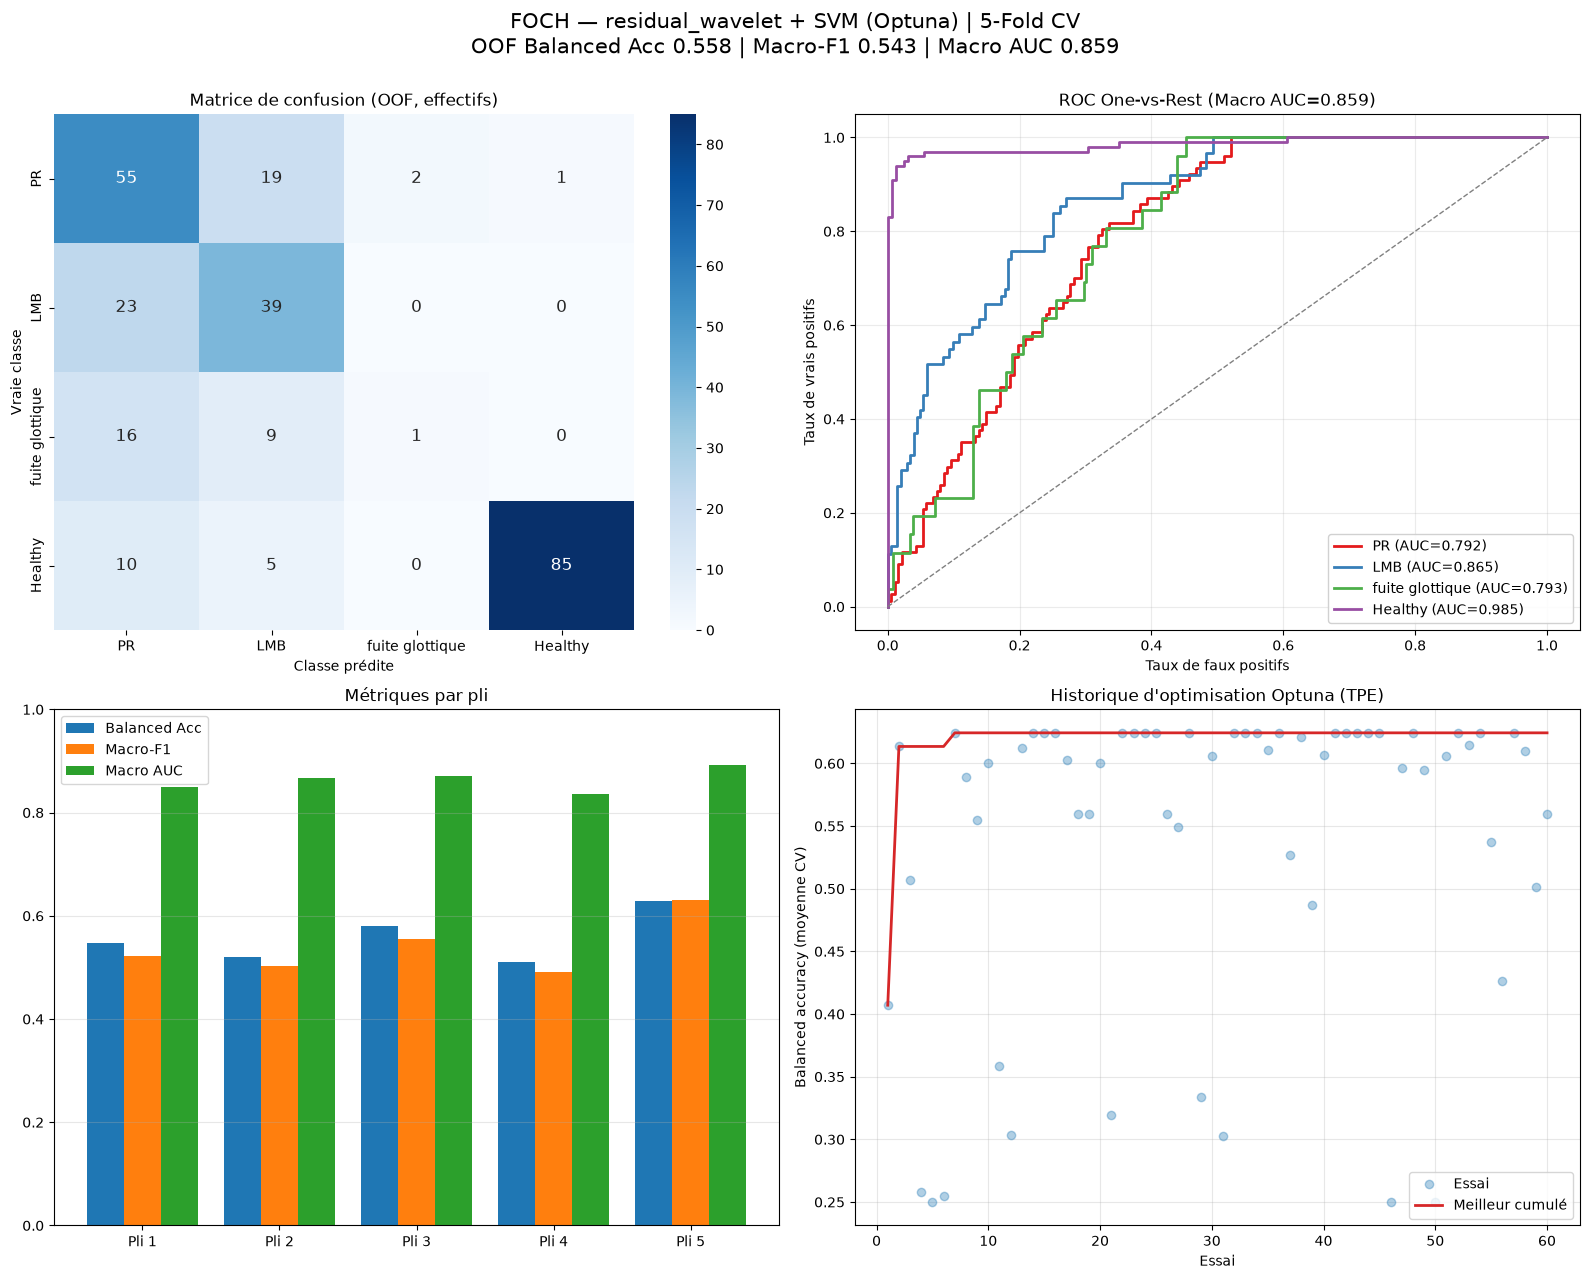


Artefacts sauvegardés dans C:/Users/AdminIA/Documents/models/.foch_métriques :
  • residual_wavelet_svm_optuna_kfold_dashboard.png
  • residual_wavelet_svm_optuna_kfold_metrics.json
  • residual_wavelet_svm_optuna_kfold_confusion.csv
  • residual_wavelet_svm_optuna_kfold_fold_metrics.csv
  • residual_wavelet_svm_optuna_kfold_features_cache.csv


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8 — Évaluation agrégée out-of-fold + tableau de bord
# ═══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.preprocessing import label_binarize

best = study.best_params
kernel = best['kernel']
gamma = best['gamma'] if kernel in ('rbf', 'poly', 'sigmoid') else 'scale'
degree = best.get('degree', 3)
class_weight = None if best['class_weight'] == 'none' else 'balanced'

oof_labels = np.full(len(df), -1, dtype=int)
oof_preds  = np.full(len(df), -1, dtype=int)
oof_probs  = np.zeros((len(df), NUM_LABELS), dtype=float)
fold_rows = []

for fold_idx in range(K_FOLDS):
    X_tr, y_tr, X_va, y_va, va_idx = _fold_train_val(fold_idx)
    pipe = _make_pipeline(best['C'], kernel, gamma, degree, class_weight)
    pipe.set_params(svm__probability=True)
    pipe.fit(X_tr, y_tr)
    probs = pipe.predict_proba(X_va)
    preds = probs.argmax(1)
    oof_probs[va_idx], oof_preds[va_idx], oof_labels[va_idx] = probs, preds, y_va

    bal = balanced_accuracy_score(y_va, preds)
    mf1 = f1_score(y_va, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(y_va, probs, multi_class='ovr', average='macro', labels=labels_idx)
    except ValueError:
        auc = float('nan')
    fold_rows.append({'fold': fold_idx + 1, 'balanced_accuracy': bal, 'macro_f1': mf1,
                       'macro_auc_ovr': auc, 'n_train': len(X_tr), 'n_val': len(X_va)})
    print(f'  Pli {fold_idx+1} : Balanced Acc {bal:.3f} | Macro-F1 {mf1:.3f} | Macro AUC {auc:.3f}')

fold_df = pd.DataFrame(fold_rows)
assert (oof_labels >= 0).all(), "Des enregistrements n'ont pas été évalués !"

print(f"\nRapport de classification agrégé (out-of-fold) :")
print(classification_report(oof_labels, oof_preds, labels=labels_idx,
                             target_names=CLASSES, digits=3, zero_division=0))

oof_bal = balanced_accuracy_score(oof_labels, oof_preds)
oof_mf1 = f1_score(oof_labels, oof_preds, average='macro', zero_division=0)
try:
    oof_auc = roc_auc_score(oof_labels, oof_probs, multi_class='ovr', average='macro', labels=labels_idx)
except ValueError:
    oof_auc = float('nan')
mean_bal, std_bal = fold_df['balanced_accuracy'].mean(), fold_df['balanced_accuracy'].std()
mean_f1,  std_f1  = fold_df['macro_f1'].mean(),          fold_df['macro_f1'].std()
mean_auc, std_auc = fold_df['macro_auc_ovr'].mean(),     fold_df['macro_auc_ovr'].std()
print(f'OOF global      — Balanced Acc {oof_bal:.4f} | Macro-F1 {oof_mf1:.4f} | Macro AUC {oof_auc:.4f}')
print(f'Moyenne/pli     — Balanced Acc {mean_bal:.4f}±{std_bal:.4f} | '
      f'Macro-F1 {mean_f1:.4f}±{std_f1:.4f} | Macro AUC {mean_auc:.4f}±{std_auc:.4f}')

print('\nPer-class AUC (one-vs-rest) et rappel :')
for i, cls in enumerate(CLASSES):
    auc_i = roc_auc_score((oof_labels == i).astype(int), oof_probs[:, i])
    recall_i = ((oof_preds == i) & (oof_labels == i)).sum() / max((oof_labels == i).sum(), 1)
    print(f'  {cls:>18}: recall={recall_i:.2f}  AUC={auc_i:.2f}')

# ── Tableau de bord (confusion, ROC, métriques par pli, historique Optuna) ────
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle(f'FOCH — {FEATURE_SET} + SVM (Optuna) | {K_FOLDS}-Fold CV\n'
             f'OOF Balanced Acc {oof_bal:.3f} | Macro-F1 {oof_mf1:.3f} | Macro AUC {oof_auc:.3f}',
             fontsize=15)

cm = confusion_matrix(oof_labels, oof_preds, labels=labels_idx)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 12})
axes[0, 0].set_title('Matrice de confusion (OOF, effectifs)')
axes[0, 0].set_ylabel('Vraie classe'); axes[0, 0].set_xlabel('Classe prédite')

oof_labels_bin = label_binarize(oof_labels, classes=labels_idx)
_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
for i, (cls, col) in enumerate(zip(CLASSES, _colors)):
    fpr, tpr, _ = roc_curve(oof_labels_bin[:, i], oof_probs[:, i])
    axes[0, 1].plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={sk_auc(fpr, tpr):.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
axes[0, 1].set_xlabel('Taux de faux positifs'); axes[0, 1].set_ylabel('Taux de vrais positifs')
axes[0, 1].set_title(f'ROC One-vs-Rest (Macro AUC={oof_auc:.3f})')
axes[0, 1].legend(loc='lower right', framealpha=0.9); axes[0, 1].grid(True, alpha=0.25)

x = np.arange(K_FOLDS); w = 0.27
axes[1, 0].bar(x - w, fold_df['balanced_accuracy'], w, label='Balanced Acc')
axes[1, 0].bar(x,     fold_df['macro_f1'],          w, label='Macro-F1')
axes[1, 0].bar(x + w, fold_df['macro_auc_ovr'],     w, label='Macro AUC')
axes[1, 0].set_title('Métriques par pli'); axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([f'Pli {i+1}' for i in range(K_FOLDS)])
axes[1, 0].set_ylim(0, 1); axes[1, 0].legend(); axes[1, 0].grid(True, axis='y', alpha=0.3)

trial_values = [t.value for t in study.trials if t.value is not None]
running_best = np.maximum.accumulate(trial_values)
axes[1, 1].plot(range(1, len(trial_values) + 1), trial_values, 'o', alpha=0.35, color='#1f77b4', label='Essai')
axes[1, 1].plot(range(1, len(running_best) + 1), running_best, '-', color='#d62728', lw=2, label='Meilleur cumulé')
axes[1, 1].set_title("Historique d'optimisation Optuna (TPE)")
axes[1, 1].set_xlabel('Essai'); axes[1, 1].set_ylabel('Balanced accuracy (moyenne CV)')
axes[1, 1].legend(loc='lower right'); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(); plt.subplots_adjust(top=0.90)
fig_path = os.path.join(METRICS_DIR, f'{RUN_NAME}_dashboard.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde des artefacts ──────────────────────────────────────────────────
import json
report_dict = classification_report(oof_labels, oof_preds, labels=labels_idx,
                                     target_names=CLASSES, output_dict=True, zero_division=0)
metrics = {
    'run_name': RUN_NAME, 'feature_set': FEATURE_SET,
    'use_residual': USE_RESIDUAL, 'use_wavelet': USE_WAVELET,
    'n_features': len(ALL_FEATURE_NAMES), 'feature_names': ALL_FEATURE_NAMES,
    'best_svm_params': best, 'best_cv_balanced_accuracy': study.best_value,
    'cv': f'StratifiedKFold(n_splits={K_FOLDS})  — mêmes plis que 10_0_foch_test_pantagruel.ipynb',
    'oof_balanced_accuracy': oof_bal, 'oof_macro_f1': oof_mf1, 'oof_macro_auc_ovr': oof_auc,
    'mean_balanced_accuracy': mean_bal, 'std_balanced_accuracy': std_bal,
    'mean_macro_f1': mean_f1, 'std_macro_f1': std_f1,
    'mean_macro_auc_ovr': mean_auc, 'std_macro_auc_ovr': std_auc,
    'per_fold': fold_rows, 'per_class_oof': report_dict,
    'classes': CLASSES, 'n_total': int(len(df)), 'n_trials': N_TRIALS,
}
with open(os.path.join(METRICS_DIR, f'{RUN_NAME}_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2, default=float)
np.savetxt(os.path.join(METRICS_DIR, f'{RUN_NAME}_confusion.csv'), cm, fmt='%d', delimiter=',')
fold_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_fold_metrics.csv'), index=False)

print(f'\nArtefacts sauvegardés dans {METRICS_DIR} :')
print(f'  • {RUN_NAME}_dashboard.png')
print(f'  • {RUN_NAME}_metrics.json')
print(f'  • {RUN_NAME}_confusion.csv')
print(f'  • {RUN_NAME}_fold_metrics.csv')
print(f'  • {RUN_NAME}_features_cache.csv')


## 9. Synthèse et journal des modifications

**Comparaison directe avec `residual_solo`** (`10_0_foch_test_pantagruel.ipynb`, mêmes plis) :
relancer ce notebook avec `FEATURE_SET = 'residual_solo'` (Cellule 1) doit retrouver des métriques
OOF proches de la référence (Balanced Acc 0.443, Macro-F1 0.414, Macro AUC 0.674) — un écart
important signalerait une différence de traitement (imputation, standardisation) plutôt qu'un
véritable effet des ondelettes. Comparer ensuite `wavelet_solo` et `residual_wavelet` sur le même
bloc PR ↔ fuite glottique.

**Pistes d'amélioration ultérieures :**
1. Si `residual_wavelet` dépasse nettement `residual_solo` sur ce bloc de confusion, envisager de
   brancher les ondelettes dans le pipeline de fusion profond (`10_0_foch_test_pantagruel.ipynb`)
   comme quatrième branche, plutôt que de rester sur ce classifieur classique.
2. `oof_proba` (Cellule 8) est un candidat naturel pour du late-fusion avec les branches WavLM/
   Pantagruel, moins risqué pour le surapprentissage qu'une concaténation d'embeddings à 3 branches
   sur ~300 échantillons.
3. Recherche sur le choix des ondelettes (`WAVELET_NAME`, `WAVELET_LEVEL`) — `db4`/niveau 5 repris
   par défaut, non ré-optimisé ici.

**Ce qui a été délibérément omis** (sur demande) : la cellule de journal persistant des runs
(`runs_log.csv`, Cellule 8b de `10_0_foch_test_pantagruel.ipynb`) n'a pas d'équivalent ici.

## Changelog

- **v0.1** — Notebook classique dérivé de `10_0_foch_test_pantagruel.ipynb` : sections 1-5
  (parsing métadonnées, appariement Saarbrücken, encodage labels, résidu vocodeur Vocos,
  `StratifiedKFold` + pool augmenté) reprises à l'identique (mêmes chemins, mêmes plis). Ajout des
  features en sous-bandes ondelettes (`db4`, niveau 5, esprit Ossonce détail/approximation).
  Remplacement du modèle de fusion tri-branche (réseau + `FocalLoss` + 30 epochs) par un `SVC`
  scikit-learn optimisé par Optuna (TPE, {N_TRIALS} essais), évalué sur les mêmes plis pour rester
  comparable à l'ablation `residual_solo`. Cellule de journal persistant des runs non reprise (sans
  utilité pour cette vérification rapide).
